# 🌍 Understanding Our 12-Channel Multispectral Data

Unlike standard RGB images, our dataset consists of **12-channel harmonized satellite imagery** (Sentinel-2/Landsat). These invisible bands and auxiliary geographical data layers are critical for accurately segmenting water bodies.



### 📊 Band Breakdown & Significance

Our model takes an input shape of `(Height, Width, 12)`. Here is what each index `[0 to 11]` represents:

#### 1. Optical & Infrared Bands (Reflectance Data)
These bands capture sunlight reflected off the Earth. The infrared spectrum is our most powerful tool for this task.
* **`Band 0` - Coastal Aerosol (~443nm):** Deep blue/violet light. Penetrates shallow water well and detects atmospheric particles.
* **`Band 1` - Blue (~490nm):** Visible blue light. Good for clear water penetration.
* **`Band 2` - Green (~560nm):** Visible green light. Highlights turbidity (muddiness) in water.
* **`Band 3` - Red (~665nm):** Visible red light. Strongly reflects off bare soil and urban areas.
* **`Band 4` - NIR (Near-Infrared, ~842nm):** **⭐ CRITICAL FOR WATER SEGMENTATION.** Water absorbs almost all NIR light (appearing pitch black), while land and vegetation reflect it heavily (appearing bright white).
* **`Band 5` - SWIR1 & `Band 6` - SWIR2 (Short-Wave Infrared):** Highly sensitive to moisture content. Helps distinguish wet soil from dry soil and penetrates thin clouds.

#### 2. Quality Assessment
* **`Band 7` - QA Band:** A pixel-level bitmask indicating the presence of clouds, cloud shadows, or snow, which could otherwise confuse the model.

#### 3. Topography & Elevation (3D Context)
Water naturally flows to and settles in areas of low elevation.
* **`Band 8` - MERIT DEM:** Digital Elevation Model with vegetation and buildings removed (bare earth elevation).
* **`Band 9` - Copernicus DEM:** Digital Surface Model that includes the heights of forests and infrastructure.

#### 4. Historical & Categorical Priors
These layers act as statistical "hints" for the neural network.
* **`Band 10` - ESA WorldCover Map:** A discrete classification map where each pixel is pre-labeled with a land cover type (e.g., Trees, Urban, Permanent Water).
* **`Band 11` - Water Occurrence Probability (JRC):** A heatmap (0-100) indicating how frequently water has been observed at this specific pixel over the past few decades.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio # For loading the images that have the extension (".tif")
import cv2
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import os
import shutil
from tqdm import tqdm
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Conv2DTranspose, Concatenate, BatchNormalization, Activation
from tensorflow.keras.models import Model


In [2]:
!pip install rasterio

In [3]:
# dataset_root_folder = "/content/drive/MyDrive/Colab_Notebooks/Projects/Water Segmentation"
# dataset_name = "data"

In [ ]:
# # os.walk() returns three values (the path, subdirectories, and files)
# for path, subdirs, files in os.walk(dataset_root_folder):
#   print(subdirs)

['Notebooks', 'data']
[]


In [ ]:
# for path, subdirs, files in os.walk(os.path.join(dataset_root_folder, dataset_name)):
#   dir_name = path.split(os.path.sep)[-1]
#   print(dir_name)

#   if dir_name == "images": # you can change it to "labels"
#     images = os.listdir(path)
#     print(images)
#     for i, image_name in enumerate(images): # get the index and the image names
#       if (image_name.endswith(".tif")): # Check the extension of the images, You can change it to ".png"

#         print(f"Image {i}: image name is {image_name}")

data
labels
images
['0.tif', '1.tif', '3.tif', '8.tif', '5.tif', '7.tif', '9.tif', '6.tif', '4.tif', '10.tif', '16.tif', '12.tif', '14.tif', '13.tif', '11.tif', '15.tif', '17.tif', '23.tif', '18.tif', '22.tif', '19.tif', '20.tif', '21.tif', '24.tif', '25.tif', '27.tif', '26.tif', '29.tif', '28.tif', '33.tif', '30.tif', '35.tif', '36.tif', '31.tif', '34.tif', '32.tif', '37.tif', '40.tif', '38.tif', '42.tif', '39.tif', '41.tif', '43.tif', '48.tif', '44.tif', '46.tif', '49.tif', '47.tif', '45.tif', '50.tif', '51.tif', '55.tif', '54.tif', '52.tif', '56.tif', '53.tif', '60.tif', '62.tif', '63.tif', '61.tif', '58.tif', '57.tif', '59.tif', '64.tif', '71.tif', '67.tif', '66.tif', '70.tif', '65.tif', '69.tif', '68.tif', '76.tif', '72.tif', '77.tif', '73.tif', '75.tif', '74.tif', '80.tif', '81.tif', '78.tif', '84.tif', '79.tif', '82.tif', '83.tif', '91.tif', '87.tif', '86.tif', '90.tif', '85.tif', '89.tif', '88.tif', '93.tif', '92.tif', '96.tif', '94.tif', '97.tif', '95.tif', '100.tif', '103.tif

# Read the images

In [ ]:
data_dir = "/content/drive/MyDrive/Colab_Notebooks/Projects/Water Segmentation/data"

In [ ]:
images_dir = os.path.join(data_dir, "images")
print(images_dir)

/content/drive/MyDrive/Colab_Notebooks/Projects/Water Segmentation/data/images


In [ ]:
files = os.listdir(images_dir)
print(files)

['0.tif', '1.tif', '3.tif', '8.tif', '5.tif', '7.tif', '9.tif', '6.tif', '4.tif', '10.tif', '16.tif', '12.tif', '14.tif', '13.tif', '11.tif', '15.tif', '17.tif', '23.tif', '18.tif', '22.tif', '19.tif', '20.tif', '21.tif', '24.tif', '25.tif', '27.tif', '26.tif', '29.tif', '28.tif', '33.tif', '30.tif', '35.tif', '36.tif', '31.tif', '34.tif', '32.tif', '37.tif', '40.tif', '38.tif', '42.tif', '39.tif', '41.tif', '43.tif', '48.tif', '44.tif', '46.tif', '49.tif', '47.tif', '45.tif', '50.tif', '51.tif', '55.tif', '54.tif', '52.tif', '56.tif', '53.tif', '60.tif', '62.tif', '63.tif', '61.tif', '58.tif', '57.tif', '59.tif', '64.tif', '71.tif', '67.tif', '66.tif', '70.tif', '65.tif', '69.tif', '68.tif', '76.tif', '72.tif', '77.tif', '73.tif', '75.tif', '74.tif', '80.tif', '81.tif', '78.tif', '84.tif', '79.tif', '82.tif', '83.tif', '91.tif', '87.tif', '86.tif', '90.tif', '85.tif', '89.tif', '88.tif', '93.tif', '92.tif', '96.tif', '94.tif', '97.tif', '95.tif', '100.tif', '103.tif', '105.tif', '98.t

In [ ]:
files[:5]

['0.tif', '1.tif', '3.tif', '8.tif', '5.tif']

In [ ]:
dir_name = "images"

In [ ]:
sample_img_path = os.path.join(data_dir,dir_name[0])
sample_img_path

'/content/drive/MyDrive/Colab_Notebooks/Projects/Water Segmentation/data/i'

In [ ]:
sample_img_path = "/content/drive/MyDrive/Colab_Notebooks/Projects/Water Segmentation/data/images/1.tif"
if sample_img_path.endswith((".tif", ".tiff")):
  with rasterio.open(sample_img_path) as src:
    img = src.read()
    print("image before movingaxis")
    print(img.shape)
    # Rasterio loads as (Channels, Height, Width). We move Channels to the end for plotting.
    # Because matplotlib expect images to have dim of (Height, Width, Channels)
    # So we move the dimension of Channels to the end Which is 12 channels
    img = np.moveaxis(img, 0, -1)
    print("image after movingaxis")
    print(img.shape)

else:
  print("Unkown file extension")

image before movingaxis
(12, 128, 128)
image after movingaxis
(128, 128, 12)


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


In [ ]:
print(f"Image Shape: {img.shape}")
print(f"Image Size: {img.size}")
print(f"Data type: {img.dtype}")
print(f"Min Valu: {img.min()}, Max Value: {img.max()}")

Image Shape: (128, 128, 12)
Image Size: 196608
Data type: int16
Min Valu: 0, Max Value: 6411


In [ ]:
img.max()

np.int16(6411)

In [ ]:
img

array([[[233, 182, 405, ..., 361,  10,   0],
        [230, 182, 427, ..., 360,  30,   0],
        [230, 174, 429, ..., 361,  10,   0],
        ...,
        [327, 299, 648, ..., 401,  30,   0],
        [327, 315, 648, ..., 402,  30,   0],
        [325, 341, 649, ..., 402,  30,   0]],

       [[263, 292, 617, ..., 361,  10,   0],
        [298, 309, 630, ..., 360,  30,   0],
        [298, 203, 414, ..., 361,  10,   0],
        ...,
        [328, 257, 527, ..., 400,  30,   0],
        [328, 418, 644, ..., 402,  10,   0],
        [333, 398, 663, ..., 403,  30,   0]],

       [[263, 369, 707, ..., 359,  30,   0],
        [298, 348, 666, ..., 360,  30,   0],
        [298, 234, 447, ..., 361,  10,   0],
        ...,
        [328, 272, 613, ..., 398,  10,   0],
        [328, 333, 576, ..., 401,  10,   0],
        [333, 300, 616, ..., 400,  10,   0]],

       ...,

       [[247, 221, 565, ..., 487,  10,   0],
        [214, 131, 335, ..., 489,  10,   0],
        [214,  91, 231, ..., 483,  10,   0

In [4]:
train_img_dir = "/content/drive/MyDrive/Colab_Notebooks/Projects/Water Segmentation/data/images"
train_img_mask = "/content/drive/MyDrive/Colab_Notebooks/Projects/Water Segmentation/data/labels"


Get Image and Mask filenames and Sort them to ensure matching

In [5]:
from numpy._core.defchararray import endswith
train_img_files = [f for f in sorted(os.listdir(train_img_dir)) if f.endswith(".tif")]
train_img_files

['0.tif',
 '1.tif',
 '10.tif',
 '100.tif',
 '101.tif',
 '102.tif',
 '103.tif',
 '104.tif',
 '105.tif',
 '106.tif',
 '107.tif',
 '108.tif',
 '109.tif',
 '11.tif',
 '110.tif',
 '111.tif',
 '112.tif',
 '113.tif',
 '114.tif',
 '115.tif',
 '116.tif',
 '117.tif',
 '118.tif',
 '119.tif',
 '12.tif',
 '120.tif',
 '121.tif',
 '122.tif',
 '123.tif',
 '124.tif',
 '125.tif',
 '126.tif',
 '127.tif',
 '128.tif',
 '129.tif',
 '13.tif',
 '130.tif',
 '131.tif',
 '132.tif',
 '133.tif',
 '134.tif',
 '135.tif',
 '136.tif',
 '137.tif',
 '138.tif',
 '139.tif',
 '14.tif',
 '140.tif',
 '141.tif',
 '142.tif',
 '143.tif',
 '144.tif',
 '145.tif',
 '146.tif',
 '147.tif',
 '148.tif',
 '149.tif',
 '15.tif',
 '150.tif',
 '151.tif',
 '152.tif',
 '153.tif',
 '154.tif',
 '155.tif',
 '156.tif',
 '157.tif',
 '158.tif',
 '159.tif',
 '16.tif',
 '160.tif',
 '161.tif',
 '162.tif',
 '163.tif',
 '164.tif',
 '165.tif',
 '166.tif',
 '167.tif',
 '168.tif',
 '169.tif',
 '17.tif',
 '170.tif',
 '171.tif',
 '172.tif',
 '173.tif',
 '17

In [6]:
train_mask_files = [f for f in sorted(os.listdir(train_img_mask)) if f.endswith(".png")]
train_mask_files

['0.png',
 '1.png',
 '10.png',
 '100.png',
 '100_184.png',
 '101.png',
 '101_89.png',
 '102.png',
 '102_179.png',
 '103.png',
 '103_225.png',
 '104.png',
 '104_20.png',
 '105.png',
 '105_148.png',
 '106.png',
 '106_267.png',
 '107.png',
 '107_59.png',
 '108.png',
 '108_236.png',
 '109.png',
 '109_223.png',
 '10_244.png',
 '11.png',
 '110.png',
 '110_287.png',
 '111.png',
 '111_121.png',
 '112.png',
 '112_78.png',
 '113.png',
 '113_44.png',
 '114.png',
 '114_220.png',
 '115.png',
 '115_49.png',
 '116.png',
 '116_250.png',
 '117.png',
 '117_97.png',
 '118.png',
 '118_125.png',
 '119.png',
 '119_222.png',
 '11_116.png',
 '12.png',
 '120.png',
 '120_305.png',
 '121.png',
 '121_142.png',
 '122.png',
 '122_257.png',
 '123.png',
 '123_145.png',
 '124.png',
 '124_95.png',
 '125.png',
 '125_201.png',
 '126.png',
 '126_110.png',
 '127.png',
 '127_54.png',
 '128.png',
 '128_294.png',
 '129.png',
 '129_177.png',
 '12_286.png',
 '13.png',
 '130.png',
 '130_256.png',
 '131.png',
 '131_185.png',
 '13

In [7]:
print(len(train_img_files))
print(len(train_mask_files))

306
456


# Handle images and masks count mismatch


In [8]:
text = '46_55.png'
set([os.path.splitext(text)[0]])

{'46_55'}

In [9]:
img_basenames = set([os.path.splitext(f)[0] for f in train_img_files])
mask_basenames = set([os.path.splitext(f)[0] for f in train_mask_files])


In [10]:
# Use Set Difference to Give me everything in the first set(img_basenames) that is missing from the second set(mask_basenames).
missing_masks = img_basenames - mask_basenames
missing_images = mask_basenames - img_basenames
print(f"Missing Masks: {len(missing_masks)}")
print(f"Missing images: {len(missing_images)}")

Missing Masks: 0
Missing images: 150


The Fix : Only Keep the filenames that exist in Both folders images and masks

In [11]:
valid_basenames = img_basenames.intersection(mask_basenames)
print(f"Valid Basenames: {len(valid_basenames)}")

Valid Basenames: 306


In [12]:
# Rebuild the lists using ONLY the valid pairs, and SORT them so they align perfectly!
train_img_files = sorted([f"{name}.tif" for name in valid_basenames])
train_mask_files = sorted([f"{name}.png" for name in valid_basenames])
len(train_img_files) == len(train_mask_files)

True

Create a folder of preprocessed data after remove the mismatch images

In [13]:
preprocessed_img_dir = "/content/drive/MyDrive/Colab_Notebooks/Projects/Water Segmentation/preprocessed_data/images/"
preprocessed_mask_dir = "/content/drive/MyDrive/Colab_Notebooks/Projects/Water Segmentation/preprocessed_data/labels/"

In [14]:
os.makedirs(preprocessed_img_dir, exist_ok=True)
os.makedirs(preprocessed_mask_dir, exist_ok=True )

## Create a copy of the matched images and masks into the preprocessed folder

In [51]:
for name in tqdm(valid_basenames):
  # Define the original raw files paths
  raw_img_path = os.path.join(train_img_dir, f"{name}.tif")
  raw_mask_path = os.path.join(train_img_mask, f"{name}.png")

  # Define the new destination paths
  new_img_path = os.path.join(preprocessed_img_dir, f"{name}.tif")
  new_mask_path = os.path.join(preprocessed_mask_dir, f"{name}.png")

  # Copy The files from the raw path to the new path
  shutil.copy(raw_img_path, new_img_path)
  shutil.copy(raw_mask_path, new_mask_path)



100%|██████████| 306/306 [06:35<00:00,  1.29s/it]


In [15]:
len(os.listdir(preprocessed_img_dir)) == len(os.listdir(preprocessed_mask_dir))

True

In [16]:
def display_image_and_mask(img_path, mask_path):
  # Use the already defined load_image function to correctly read the .tif file
  img_multichannel = load_image(img_path)

  # For display, select a subset of channels, e.g., Red (Band 3), Green (Band 2), Blue (Band 1).
  # Adjust these indices if your desired visual representation changes.
  # Normalizing to 0-1 for display purposes.
  # Assuming bands are 0-indexed: Band 3 (Red) is index 3, Band 2 (Green) is index 2, Band 1 (Blue) is index 1
  display_img = img_multichannel[:, :, [3, 2, 1]].astype(np.float32) # Select RGB channels
  display_img = (display_img - display_img.min()) / (display_img.max() - display_img.min()) # Normalize for display

  mask = Image.open(mask_path)

  # Plot the image and mask side by side
  fig, axes = plt.subplots(1,2,figsize=(10,5))
  axes[0].imshow(display_img)
  axes[0].set_title("Image (RGB)")
  axes[0].axis("off")

  axes[1].imshow(mask,cmap="gray")
  axes[1].set_title("Mask")
  axes[1].axis("off")
  plt.show()

In [17]:
def load_image(img_path):
  """
  Loads a 12-channel .tif image and normalize it to [0,1].
  """
  # img_path is expected to be a Python string here, provided by process_image_for_tf
  with rasterio.open(img_path) as src:
    img = src.read()
    img = np.moveaxis(img, 0,-1) # Converts (12,H,W) to (H, W , 12)
  return img

In [18]:
def normalize_image(img):
  """
  Normalize the image to values betwen 0 and 1
  """
  img = img.astype(np.float32) / 10000.0
  img = np.clip(img, 0.0, 1.0)
  return img

# Visualize the images and it's mask Side by Side

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


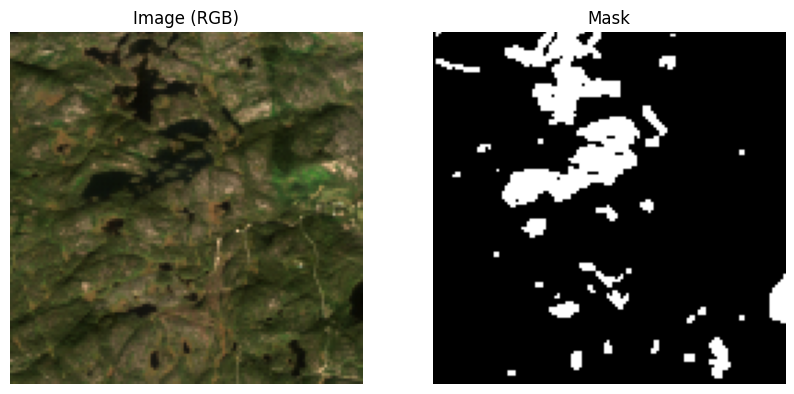

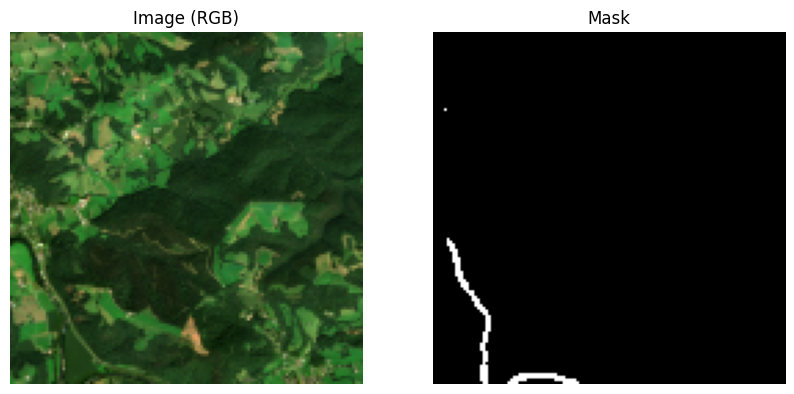

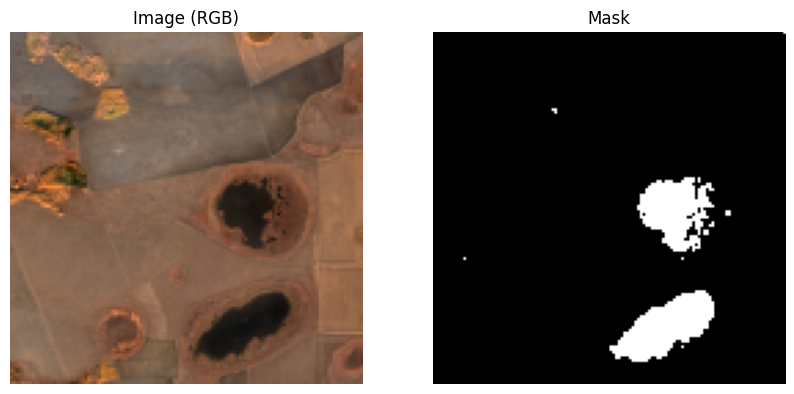

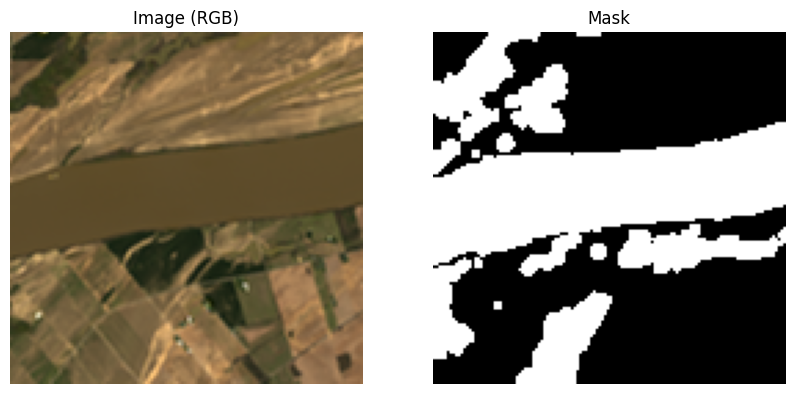

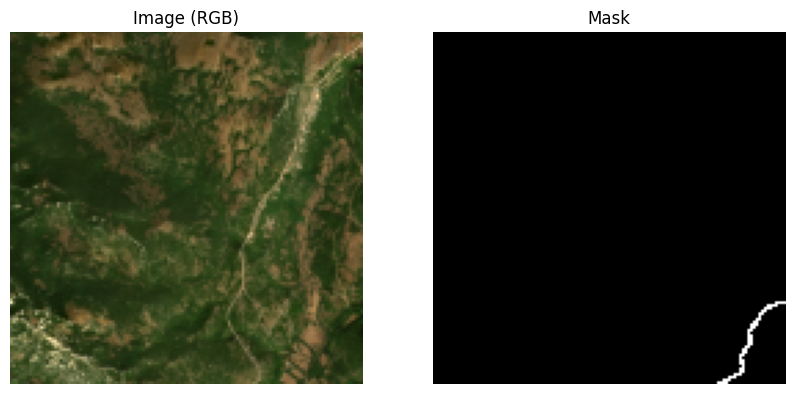

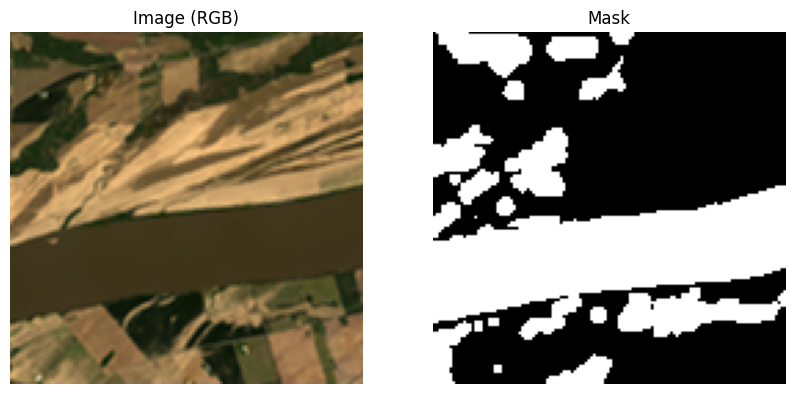

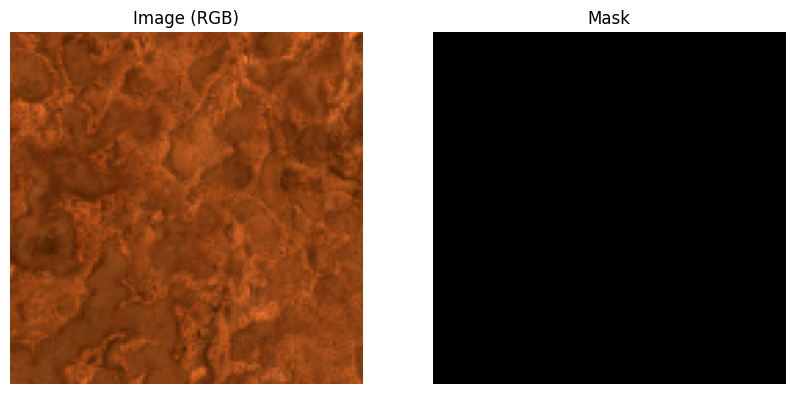

In [19]:
# check that the number of images match the number of masks

if len(train_img_files) != len(train_mask_files):
  print("Not match")
else:

  # Display the first 7 image-mask pairs
  for img_file, mask_file in zip(train_img_files[:7], train_mask_files[:7]):

     # get the full path for the img and masks
     img_path = os.path.join(preprocessed_img_dir, img_file)
     mask_path = os.path.join(preprocessed_mask_dir, mask_file)

     display_image_and_mask(img_path=img_path, mask_path=mask_path)

Wrap our Custom Python Functions we have created so tensorflow can run them and understand the python code

# ⚙️ Building the Custom TensorFlow Data Pipeline

For this water segmentation task, we are working with **12-channel multispectral satellite imagery** saved as `.tif` files, and binary masks saved as `.png` files.

Because of the complex nature of this data, we cannot use standard high-level deep learning data loaders (like `tf.keras.preprocessing.ImageDataGenerator`). Instead, we must build a highly optimized `tf.data.Dataset` pipeline.

### 🚫 Why `ImageDataGenerator` Fails Here
1. **Channel Limitations:** `ImageDataGenerator` natively supports grayscale (1-channel) or RGB (3-channel) images. It will crash or silently drop 9 of our crucial bands if fed a 12-channel image.
2. **Scientific File Formats:** Standard loaders use libraries like PIL, which struggle with multi-band, georeferenced `.tif` files. We **must** use `rasterio` to safely extract the data.
3. **Improper Normalization:** Standard image scalers use `rescale=1./255`. However, raw satellite reflectance data is stored as 16-bit integers (`uint16`) scaled by 10,000. Dividing by 255 would destroy the data distribution.

---

### 🛠️ The Architecture of Our Pipeline

To solve this, we split our data loading into three modular steps:

[Image of TensorFlow data pipeline]

#### 1. Python Utility Functions (`load_image` & `normalize_image`)
These functions do the heavy lifting in pure Python:
* **`rasterio.open()`**: Safely reads all 12 bands of the `.tif` file.
* **`np.moveaxis()`**: `rasterio` loads images as `(Channels, Height, Width)`. We move the channels to the end `(Height, Width, Channels)` to match TensorFlow's expected Conv2D input format.
* **`img / 10000.0`**: We reverse the space agency's storage scaling, bringing the true physical reflectance values back down to a decimal range that the neural network can mathematically process without exploding gradients.

#### 2. The TensorFlow Bridge (`process_image_for_tf` & `process_mask_for_tf`)
TensorFlow trains models at lightning speed by converting its operations into a compiled C++ computational graph. Because TensorFlow's C++ graph does not know how to run Python libraries like `rasterio` or `cv2`, we create these wrapper functions. They decode TensorFlow's byte-string file paths into standard Python strings so our utility functions can read them.

#### 3. The Parser (`tf_parse`)
This is the official translator for the `tf.data.Dataset`:
* **`tf.py_function`**: This acts as a bridge. It tells TensorFlow to temporarily pause the C++ graph, jump out to Python, run our custom loading wrappers, and bring the resulting arrays back into the pipeline as `tf.float32` tensors.
* **`set_shape()`**: When data passes through the `tf.py_function` black box, TensorFlow forgets its dimensions. We explicitly set the shapes to `[128, 128, 12]` for the images and `[128, 128, 1]` for the masks. The U-Net requires these explicit shapes to compile successfully.

By structuring the pipeline this way, we achieve the perfect balance: the flexibility of Python (`rasterio`/`cv2`) combined with the extreme speed and GPU-prefetching capabilities of the `tf.data.Dataset` engine!

In [20]:
def process_image_for_tf(image_path_tensor):
  # image_path_tensor is a tf.Tensor object
  path = image_path_tensor.numpy().decode("utf-8") # Correctly get bytes from tf.Tensor, then decode

  img = load_image(path)
  img = normalize_image(img)
  return img

In [21]:
def process_mask_for_tf(mask_path_tensor):
  # mask_path_tensor is a tf.Tensor object
  path = mask_path_tensor.numpy().decode("utf-8") # Correctly get bytes from tf.Tensor, then decode
  mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
  mask = mask.astype(np.float32) / 255.0
  mask = np.expand_dims(mask, axis=-1) # Change (128,128) to (128, 128,1) for the u-net model
  return mask

In [22]:
def tf_parse(image_path, mask_path):
  image = tf.py_function(process_image_for_tf, [image_path], tf.float32) # Use the wrapper function
  mask = tf.py_function(process_mask_for_tf, [mask_path], tf.float32)

  image.set_shape([128, 128, 12])
  mask.set_shape([128,128,1])

  return image, mask

# Load and preprocess Images

In [23]:
img = load_image(img_path)
img.shape

(128, 128, 12)

In [24]:
image_files = sorted([os.path.join(preprocessed_img_dir, f) for f in os.listdir(preprocessed_img_dir) if f.endswith(".tif")])
len(image_files)

306

In [25]:
mask_files = sorted([os.path.join(preprocessed_mask_dir, f ) for f in os.listdir(preprocessed_mask_dir) if f.endswith(".png")])
len(mask_files)

306

# Split the Data

Split the file paths

In [26]:
# 70% >> Train ,, 30% >> Temp
X_train, x_temp , y_train, y_temp = train_test_split(image_files, mask_files, test_size=0.3, random_state=42)
# 30% Temp >>> 15% Test
#          >>> 15% Valid

X_test, X_val, y_test, y_val = train_test_split(x_temp,y_temp, test_size=0.5, random_state=42)

len(X_train), len(X_val), len(X_test), len(y_train), len(y_val), len(y_test)

(214, 46, 46, 214, 46, 46)

In [27]:
dataset = tf.data.Dataset.from_tensor_slices((X_train,y_train))
dataset # Returns a Tensorflow object that combine the X_train and y_train

<_TensorSliceDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.string, name=None))>

In [28]:
def get_dataset(X_paths, y_paths, batch_size=16, is_training=False):
  """
    Creates an optimized TensorFlow Dataset pipeline for multispectral satellite imagery.

    This function takes raw file paths, pairs them, and builds a high-performance
    data loader that applies preprocessing, batching, and GPU prefetching.

    Args:
        x_paths (list of str): A list of file paths to the 12-channel .tif input images.
        y_paths (list of str): A list of file paths to the corresponding .png binary masks.
        batch_size (int, optional): The number of image/mask pairs to load per batch. Defaults to 16.
        is_training (bool, optional): A flag to enable data shuffling. Should be True for
                                      the training set and False for validation/testing. Defaults to False.

    Returns:
        tf.data.Dataset: A highly optimized, ready-to-train TensorFlow dataset object
                         yielding batches of shape (batch_size, 128, 128, 12) and (batch_size, 128, 128, 1).
    """
  # Create the dataset from the file paths
  dataset = tf.data.Dataset.from_tensor_slices((X_paths, y_paths))
  # If this is the training dataset, shuffle the order of the files
  # We set the buffer_size to the full length of the dataset for a perfect, completely random shuffle
  if is_training:
    dataset = dataset.shuffle(buffer_size=len(X_paths))
  # Apply our custom parsing function (tf_parse) to every file path
  # num_parallel_calls=tf.data.AUTOTUNE tells TF to use all available CPU cores to open multiple files at once
  dataset = dataset.map(tf_parse, num_parallel_calls=tf.data.AUTOTUNE)
  dataset = dataset.batch(batch_size) # Add the batch dimension
  # This tells the CPU to prepare the next batch of images in the background
  # while the GPU is actively training on the current batch, preventing bottlenecks.
  dataset = dataset.prefetch(tf.data.AUTOTUNE)
  return dataset

CREATE The DATASET

In [29]:
train_dataset = get_dataset(X_train, y_train, batch_size=8, is_training=True)
val_dataset = get_dataset(X_val, y_val, batch_size=8, is_training=False)
test_dataset = get_dataset(X_test, y_test, batch_size=8, is_training=False)

In [30]:
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 12), dtype=tf.float32, name=None), TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None))>

In [31]:
images, masks = next(iter(train_dataset))
images.shape

TensorShape([8, 128, 128, 12])

In [32]:
masks.shape

TensorShape([8, 128, 128, 1])

# Visualize the images that come from train_dataset

In [33]:
def display_array_and_mask(img_array, mask_array):
    """Visualizes arrays directly from the tf.data.Dataset batch"""

    # 1. Extract RGB channels (Bands 3, 2, 1) and normalize for display
    display_img = np.stack([img_array[:,:,3], img_array[:,:,2], img_array[:,:,1]], axis=-1)
    display_img = (display_img - np.min(display_img)) / (np.max(display_img) - np.min(display_img) + 1e-8)

    # 2. Plot side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(display_img)
    axes[0].set_title("Image (RGB)")
    axes[0].axis("off")

    # mask_array is (128, 128, 1), so we slice [:, :, 0] to make it (128, 128) for matplotlib
    axes[1].imshow(mask_array[:, :, 0], cmap="gray")
    axes[1].set_title("Mask")
    axes[1].axis("off")

    plt.show()

Displaying Pair 1


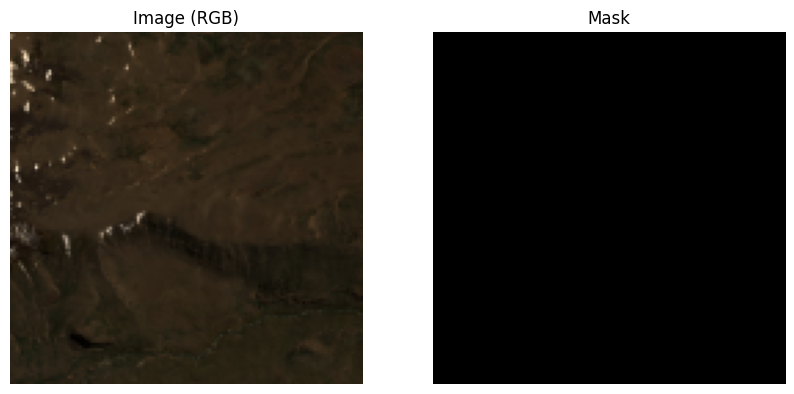

Displaying Pair 2


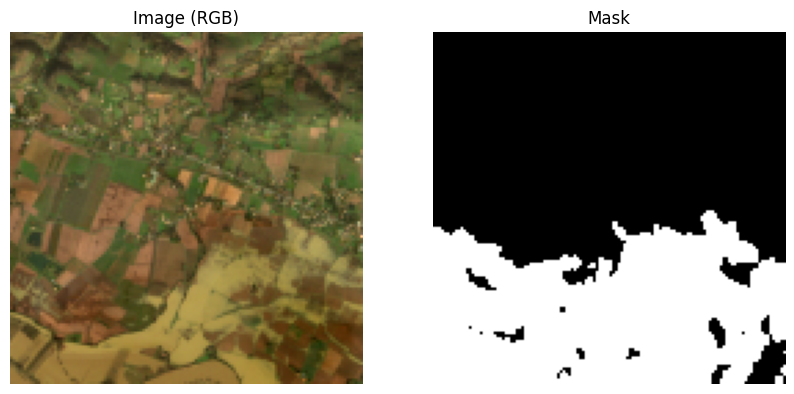

Displaying Pair 3


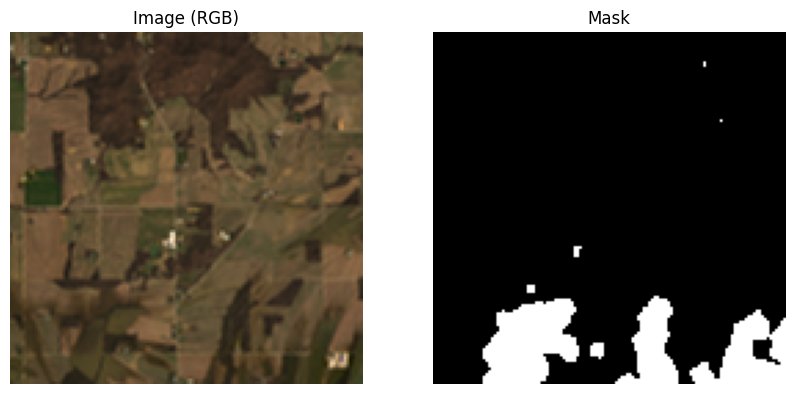

In [34]:
# Loop through the first 3 images in the batch we just generated
for i in range(3):
    print(f"Displaying Pair {i+1}")
    display_array_and_mask(images[i].numpy(), masks[i].numpy())

# Build U-Net Architecture


Create Our Helper functions

In [35]:
def conv_block(inputs, num_filters):
  """ A Standard Convolution Block for the U-Net Architecture"""
  # Apply the first Conv2D layer to the 'inputs' tensor
  x = Conv2D(num_filters, 3, padding="same", kernel_initializer="he_normal")(inputs)
  x = BatchNormalization()(x)
  x = Activation("relu")(x)

  # Apply the second Conv2D layer to the output of the previous activation
  x = Conv2D(num_filters, 3, padding="same", kernel_initializer="he_normal")(x)
  x = BatchNormalization()(x)
  x = Activation("relu")(x)

  return x

In [36]:
def encoder_block(inputs, num_filters):
    """The downward path: processes the image and then shrinks it."""
    # Process the features
    x = conv_block(inputs, num_filters)
    # Shrink the image size by half (e.g., 128x128 -> 64x64)
    p = MaxPooling2D((2, 2))(x)

    # We return BOTH 'x' (for the skip connection later) and 'p' (to continue downward)
    return x, p

In [37]:
def decoder_block(inputs, skip_features, num_filters):
    """The upward path: expands the image and merges it with the skip connections."""
    # Expand the image size by double (e.g., 64x64 -> 128x128)
    x = Conv2DTranspose(num_filters, (2, 2), strides=2, padding="same")(inputs)

    # GLUE the expanding image together with the skipped features from the encoder
    x = Concatenate()([x, skip_features])

    # Process the merged features
    x = conv_block(x, num_filters)

    return x

In [38]:
def build_unet(input_shape=(128, 128, 12)):
    # --- INPUT ---
    inputs = Input(input_shape)

    # --- ENCODER (The Left Side of the "U") ---
    # s = skip connection output, p = pooled output to go to the next level
    s1, p1 = encoder_block(inputs, 64)   # 128x128 -> 64x64
    s2, p2 = encoder_block(p1, 128)      # 64x64 -> 32x32
    s3, p3 = encoder_block(p2, 256)      # 32x32 -> 16x16
    s4, p4 = encoder_block(p3, 512)      # 16x16 -> 8x8

    # --- BOTTLENECK (The Bottom of the "U") ---
    b1 = conv_block(p4, 1024)            # Stays 8x8, but has 1024 feature channels!

    # --- DECODER (The Right Side of the "U") ---
    d1 = decoder_block(b1, s4, 512)      # 8x8 -> 16x16 (merged with s4)
    d2 = decoder_block(d1, s3, 256)      # 16x16 -> 32x32 (merged with s3)
    d3 = decoder_block(d2, s2, 128)      # 32x32 -> 64x64 (merged with s2)
    d4 = decoder_block(d3, s1, 64)       # 64x64 -> 128x128 (merged with s1)

    # --- OUTPUT ---
    # We use exactly 1 filter because we only want a 1-channel output (the mask).
    # We use "sigmoid" because we want every pixel to be a probability between 0.0 (Land) and 1.0 (Water).
    outputs = Conv2D(1, 1, padding="same", activation="sigmoid")(d4)

    # Compile the final architecture
    model = Model(inputs, outputs, name="Water_Segmentation_UNet")
    return model

# Instantiate the model
model = build_unet()
model.summary()

Model: "Water_Segmentation_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      6,976 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,060,481 (118.49 MB)

 Trainable params: 31,048,705 (118.44 MB)

 Non-trainable params: 11,776 (46.00 KB)

CREATE THE Evaluation metric IOU

In [39]:
import tensorflow.keras.backend as K

def iou_metric(y_true, y_pred):
    """Calculates the Intersection over Union (IoU) metric."""
    # Convert the predicted probabilities (0.0 to 1.0) into a strict binary mask (0 or 1)
    y_pred = K.cast(K.greater(y_pred, 0.5), K.floatx())

    # Calculate intersection and union
    intersection = K.sum(y_true * y_pred)
    union = K.sum(y_true) + K.sum(y_pred) - intersection

    # Add a tiny epsilon to prevent division by zero
    return (intersection + K.epsilon()) / (union + K.epsilon())

In [40]:
from tensorflow.keras.optimizers import Adam

# Compile the U-Net
model.compile(
    optimizer=Adam(learning_rate=1e-4), # A small learning rate is safer for complex satellite data
    loss='binary_crossentropy',
    metrics=[iou_metric, 'accuracy']    # We track accuracy just for reference, but IoU is our main focus
)

print("Model successfully compiled!")

Model successfully compiled!


In [41]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

callbacks = [
    # 1. Save the best model automatically (so you don't lose it if Colab crashes)
    ModelCheckpoint(
        filepath='best_unet_water_model.h5',
        monitor='val_iou_metric',
        mode='max', # We want maximum IoU
        save_best_only=True,
        verbose=1
    ),

    # 2. Stop training if the model stops improving (prevents overfitting)
    EarlyStopping(
        monitor='val_iou_metric',
        mode='max',
        patience=10, # Wait 10 epochs without improvement before stopping
        restore_best_weights=True,
        verbose=1
    ),

    # 3. Slow down the learning rate when the model gets stuck
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2, # Reduce learning rate by 80%
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
EPOCHS = 50 # EarlyStopping will likely halt it before it hits 50

print("Starting training...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

Starting training...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


 4/27 ━━━━━━━━━━━━━━━━━━━━ 6:51 18s/step - accuracy: 0.1987 - iou_metric: 8.9179e-04 - loss: 0.9294